# 03 — Modélisation & Évaluation

**Objectifs de cette étape :**
- Benchmark de 3 modèles : Ridge Regression, Random Forest, XGBoost
- Split temporel 80/20 (pas de shuffle — respect de l'ordre chronologique)
- Optimisation des hyperparamètres du meilleur modèle (GridSearchCV)
- Analyse SHAP pour l'interprétabilité des prédictions






.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv("../data/steel_features.csv")

X = df.drop(columns=['Usage_kWh', 'date'])
y = df['Usage_kWh']

split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Fonction d'évaluation
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:25s} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.4f}")
    return rmse

results = {}

In [2]:
# 1. Ridge Regression (baseline)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
results['Ridge'] = evaluate('Ridge Regression', y_test, ridge.predict(X_test))

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results['Random Forest'] = evaluate('Random Forest', y_test, rf.predict(X_test))

# 3. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
results['XGBoost'] = evaluate('XGBoost', y_test, xgb_model.predict(X_test))

Ridge Regression          | RMSE: 6.625 | MAE: 4.401 | R²: 0.9555
Random Forest             | RMSE: 2.358 | MAE: 0.954 | R²: 0.9944
XGBoost                   | RMSE: 1.971 | MAE: 0.965 | R²: 0.9961


In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid.best_params_}")
evaluate('XGBoost optimisé', y_test, grid.best_estimator_.predict(X_test))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500, 'subsample': 1.0}
XGBoost optimisé          | RMSE: 1.750 | MAE: 0.927 | R²: 0.9969


np.float64(1.7498897791095052)

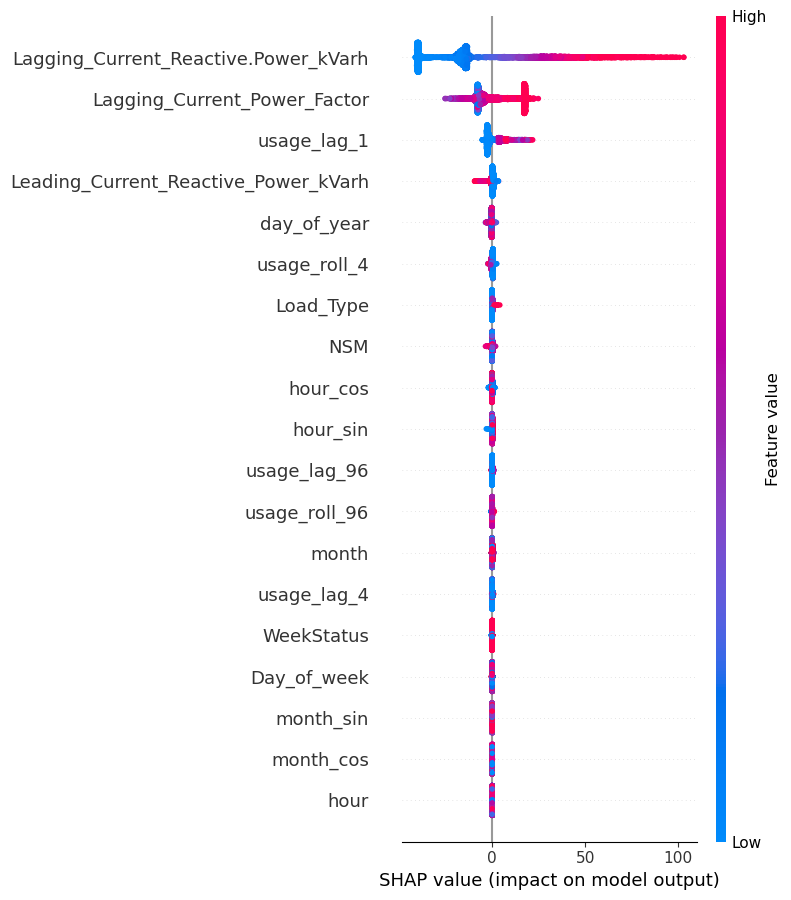

In [5]:
import shap

best_model = grid.best_estimator_

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Plot des features les plus importantes
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

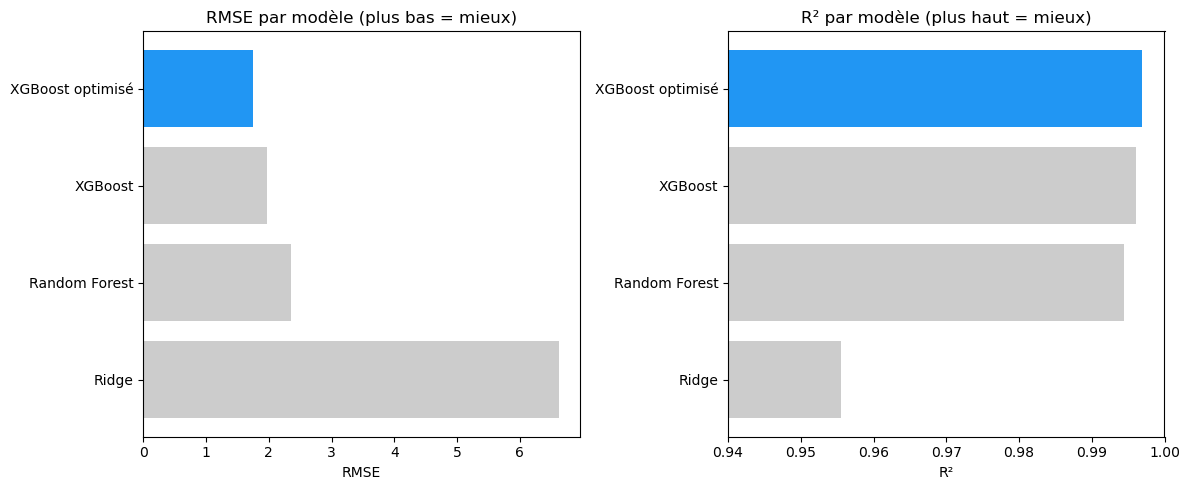

In [6]:
models = ['Ridge', 'Random Forest', 'XGBoost', 'XGBoost optimisé']
rmses = [6.625, 2.358, 1.971, 1.750]
r2s = [0.9555, 0.9944, 0.9961, 0.9969]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(models, rmses, color=['#ccc', '#ccc', '#ccc', '#2196F3'])
axes[0].set_title('RMSE par modèle (plus bas = mieux)')
axes[0].set_xlabel('RMSE')

axes[1].barh(models, r2s, color=['#ccc', '#ccc', '#ccc', '#2196F3'])
axes[1].set_title('R² par modèle (plus haut = mieux)')
axes[1].set_xlabel('R²')
axes[1].set_xlim(0.94, 1.0)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()